# **SELECTION METHODS**

Roulette_Wheel_Selection

In [ ]:
def roulette_wheel_selection(population, fitness):
    fitness = np.array(fitness)

    fitness = fitness - fitness.min() + 1e-6

    probs = fitness / fitness.sum()
    idx = np.random.choice(len(population), p=probs)

    return population[idx]

Tournament_Selection

In [ ]:
def tournament_selection(population, fitness, k=3):
    selected_idx = np.random.choice(len(population), k)
    best = selected_idx[np.argmax(fitness[selected_idx])]
    return population[best]

# **EXPERIMENT:SELECTION_COMPARISON**

In [ ]:
def run_selection_experiment(population, fitness, method, n_trials=100):
    selected_features = []

    for _ in range(n_trials):
        if method == "roulette":
            individual = roulette_wheel_selection(population, fitness)
        elif method == "tournament":
            individual = tournament_selection(population, fitness, k=3)
        else:
            raise ValueError("Unknown method")

        selected_features.append(np.sum(individual))

    return selected_features

In [ ]:
np.random.seed(42)

pop = initialize_population(50, n_features, method="uniform")
fitness_vals = evaluate_population(pop, X_train, y_train, GA_CONFIG, seed=42)

roulette_results = run_selection_experiment(pop, fitness_vals, "roulette")
tournament_results = run_selection_experiment(pop, fitness_vals, "tournament")

In [ ]:
print("=== Comparison Results ===")
print(f"Roulette → Mean: {np.mean(roulette_results):.2f}, Std: {np.std(roulette_results):.2f}")
print(f"Tournament → Mean: {np.mean(tournament_results):.2f}, Std: {np.std(tournament_results):.2f}")
print("Best Roulette:", max(roulette_results))
print("Best Tournament:", max(tournament_results))

=== Comparison Results ===

Roulette → Mean: 14.63, Std: 2.39

Tournament → Mean: 12.68, Std: 1.83

Best Roulette: 21

Best Tournament: 19

# **VISUALIZATION**

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(roulette_results, bins=10, alpha=0.6, label="Roulette Wheel")
plt.hist(tournament_results, bins=10, alpha=0.6, label="Tournament")

plt.xlabel("Number of Selected Features")
plt.ylabel("Frequency")
plt.title("Selection Methods Comparison")
plt.legend()

plt.show()

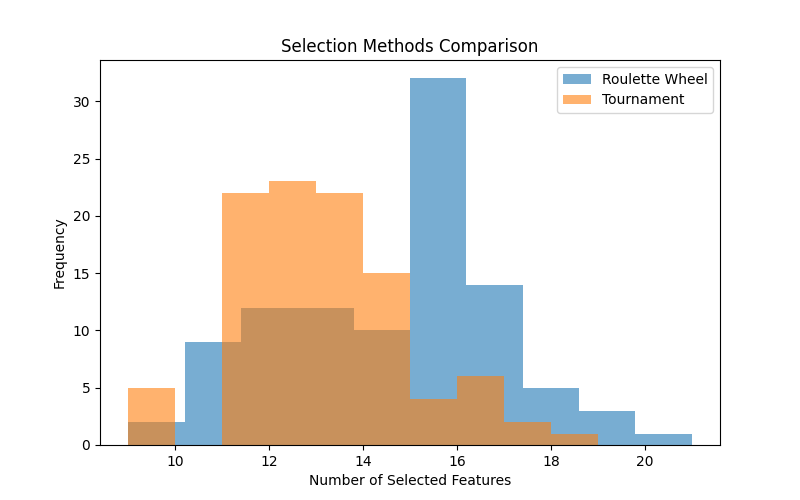